# Beginner Walkthrough: Invoice Risk Notebook

This notebook recreates your original workflow in a beginner-friendly way.

Goals:
1. Build clean tables from SQL.
2. Understand `purchase_agg_df` and `df`.
3. Understand `ttest_ind` and what it tells us.
4. Train simple ML models to predict `flag_invoice`.

## Core Concepts (Very Important)

- **DataFrame (`df`)**: A table in Python (rows and columns), like an Excel sheet.
- **Aggregation**: Combining many detailed rows into summary values (sum, count, average).
- **Join**: Merging two tables using a common key (`PONumber`).
- **Feature**: Input column used by ML (example: `invoice_dollars`).
- **Label/Target**: What we want to predict (`flag_invoice`).
- **`ttest_ind`**: A statistical test that compares the means of two independent groups.
- **p-value**: If p-value < 0.05, we usually say the difference is statistically significant.

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, make_scorer, f1_score

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

In [2]:
# Robust DB path detection so this notebook can run from different working directories.
candidate_paths = [
    Path("data/inventory.db"),
    Path("../data/inventory.db"),
    Path(r"E:/ML Project/data/inventory.db"),
]

existing = [p for p in candidate_paths if p.exists()]
if not existing:
    raise FileNotFoundError("Could not find inventory.db in expected locations.")

DB_PATH = existing[0]
conn = sqlite3.connect(DB_PATH)
print(f"Connected to: {DB_PATH.resolve()}")

Connected to: E:\ML Project\data\inventory.db


## 1) Build `purchase_agg_df`

`purchases` table usually has multiple rows per PO (purchase order).
We aggregate to one row per `PONumber` so we can join with invoice data.

In [3]:
purchase_agg_df = pd.read_sql_query(
    """
    SELECT
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_item_quantity,
        SUM(p.Dollars) AS total_item_dollars,
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
    """,
    conn,
)

print("Shape:", purchase_agg_df.shape)
purchase_agg_df.head()

Shape: (5543, 5)


,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271


### What `purchase_agg_df` means

Each row is one PO, with summary values from item-level purchase rows:
- `total_brands`: how many unique brands were in that PO.
- `total_item_quantity`: total quantity across all purchase rows.
- `total_item_dollars`: total amount across all purchase rows.
- `avg_receiving_delay`: average days from PO date to receiving date.

So this table gives a **purchase-side summary** per PO.

In [4]:
purchase_agg_df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
PONumber,5543.0,10889.419087,1600.859969,8106.00,9503.500000,10890.000000,12275.500000,13661.00
total_brands,5543.0,41.312466,76.940674,1.00,3.000000,7.000000,46.000000,807.00
total_item_quantity,5543.0,6058.880931,14453.338164,1.00,83.000000,423.000000,5100.500000,141660.00
total_item_dollars,5543.0,58073.383642,140234.031377,4.14,967.810000,4765.450000,44587.175000,1660435.88
avg_receiving_delay,5543.0,7.671541,1.824496,3.00,6.129178,7.744898,9.083804,13.00


## 2) Build invoice view and combined `df`

First, get invoice-side columns. Then join invoice data with purchase summary.

In [5]:
invoice_df = pd.read_sql_query(
    """
    SELECT
        vi.PONumber,
        vi.Quantity AS invoice_quantity,
        vi.Dollars AS invoice_dollars,
        vi.Freight,
        (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
        (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay
    FROM vendor_invoice vi
    """,
    conn,
)

print("Shape:", invoice_df.shape)
invoice_df.head()

Shape: (5543, 6)


,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0


In [6]:
df = pd.read_sql_query(
    """
    WITH purchase_agg AS (
        SELECT
            p.PONumber,
            COUNT(DISTINCT p.Brand) AS total_brands,
            SUM(p.Quantity) AS total_item_quantity,
            SUM(p.Dollars) AS total_item_dollars,
            AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
        FROM purchases p
        GROUP BY p.PONumber
    )
    SELECT
        vi.PONumber,
        vi.Quantity AS invoice_quantity,
        vi.Dollars AS invoice_dollars,
        vi.Freight,
        (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
        (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
        pa.total_brands,
        pa.total_item_quantity,
        pa.total_item_dollars,
        pa.avg_receiving_delay
    FROM vendor_invoice vi
    LEFT JOIN purchase_agg pa ON vi.PONumber = pa.PONumber
    """,
    conn,
)

print("Shape:", df.shape)
df.head()

Shape: (5543, 10)


,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809


### What `df` means

`df` is your **main modeling table**.

Each row has both:
- invoice-side information (`invoice_dollars`, `Freight`, timing columns)
- purchase-side summary (`total_item_dollars`, `avg_receiving_delay`, etc.)

This lets you compare invoice vs purchase behavior for the same PO.

## 3) Create a risk label (`flag_invoice`)

You used a rule-based definition:
- Flag = 1 if invoice amount and purchase total differ by more than 5
- OR average receiving delay is more than 10 days
- Else Flag = 0

In [8]:
def create_invoice_risk_label(row):
    # Rule 1: large mismatch between invoice dollars and summed purchase dollars
    if abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5:
        return 1

    # Rule 2: unusually high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1

    return 0


df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)

print(df["flag_invoice"].value_counts())
print("Class ratio:")
print((df["flag_invoice"].value_counts(normalize=True) * 100).round(2))

flag_invoice
0    3693
1    1850
Name: count, dtype: int64
Class ratio:
flag_invoice
0    66.62
1    33.38
Name: proportion, dtype: float64


In [9]:
flagged = df[df["flag_invoice"] == 1]
normal = df[df["flag_invoice"] == 0]

print("Flagged rows:", len(flagged))
print("Normal rows:", len(normal))

flagged.head(3)

Flagged rows: 1850
Normal rows: 3693


,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000,1
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333,1
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130,1


## 4) Quick relationship view (correlation heatmap)

High correlation means columns move together.
It does **not** prove cause-and-effect.

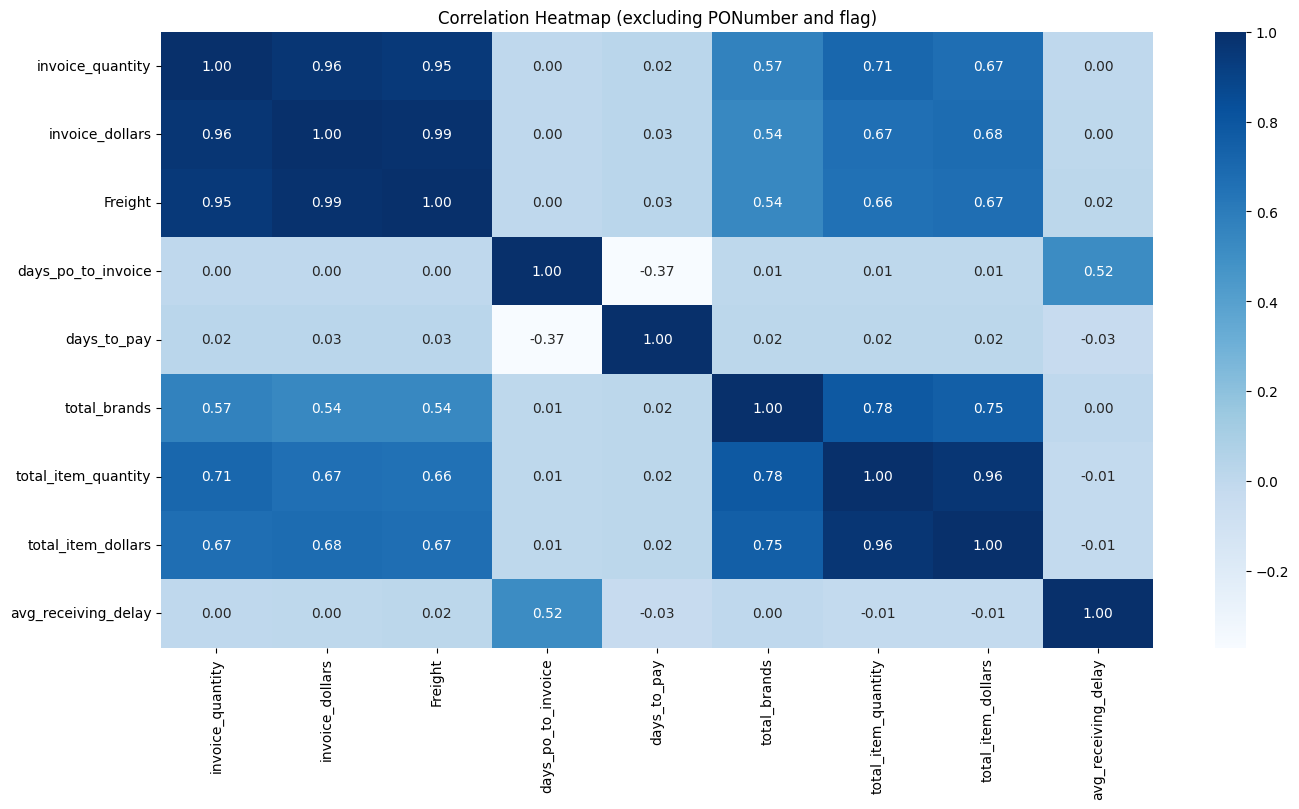

In [10]:
plt.figure(figsize=(16, 8))
sns.heatmap(df.iloc[:, 1:-1].corr(), annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlation Heatmap (excluding PONumber and flag)")
plt.show()

## 5) `ttest_ind`: what it is and why you used it

You split data into 2 groups:
- Group A: flagged invoices (`flag_invoice = 1`)
- Group B: normal invoices (`flag_invoice = 0`)

Then for each metric, you tested whether the average value differs between the two groups.

`ttest_ind(groupA, groupB, equal_var=False)` is Welch's t-test, which is safer when group variances are not equal.

In [11]:
metrics = [
    "invoice_quantity",
    "invoice_dollars",
    "Freight",
    "days_po_to_invoice",
    "days_to_pay",
    "total_brands",
    "total_item_quantity",
    "total_item_dollars",
    "avg_receiving_delay",
]

significant_features = []
non_significant_features = []
results = []

for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False,
    )

    row = {
        "metric": metric,
        "flagged_mean": round(float(flagged_mean), 2),
        "normal_mean": round(float(normal_mean), 2),
        "t_stat": round(float(t_stat), 3),
        "p_value": round(float(p_value), 6),
        "significant_at_0_05": bool(p_value < 0.05),
    }
    results.append(row)

    if p_value < 0.05:
        significant_features.append(metric)
    else:
        non_significant_features.append(metric)

results_df = pd.DataFrame(results).sort_values("p_value")
results_df

,metric,flagged_mean,normal_mean,t_stat,p_value,significant_at_0_05
3,days_po_to_invoice,17.23,16.02,13.753,0.000000,True
8,avg_receiving_delay,8.47,7.27,22.295,0.000000,True
7,total_item_dollars,65600.61,54302.64,2.652,0.008047,True
1,invoice_dollars,65600.61,54302.64,2.652,0.008047,True
2,Freight,334.02,276.89,2.646,0.008177,True
0,invoice_quantity,6728.28,5723.55,2.304,0.021304,True
6,total_item_quantity,6728.28,5723.55,2.304,0.021305,True
5,total_brands,42.29,40.82,0.662,0.507722,False
4,days_to_pay,35.42,35.49,-0.396,0.692428,False


In [12]:
print("Significant features (p < 0.05):", significant_features)
print("Non-significant features:", non_significant_features)

Significant features (p < 0.05): ['invoice_quantity', 'invoice_dollars', 'Freight', 'days_po_to_invoice', 'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']
Non-significant features: ['days_to_pay', 'total_brands']


### Important interpretation of `ttest_ind` results

- A small p-value means the group means are probably different.
- It does **not** tell you why they differ.
- It does **not** guarantee practical/business impact.

Also, your label itself depends on `invoice_dollars`, `total_item_dollars`, and `avg_receiving_delay`.
So it is expected these appear very strong.

In [14]:
# Extra diagnostic: check overlap/duplication between invoice and purchase totals.
qty_equal_ratio = (df["invoice_quantity"] == df["total_item_quantity"]).mean()
dol_equal_ratio = (df["invoice_dollars"].round(2) == df["total_item_dollars"].round(2)).mean()

print(f"invoice_quantity == total_item_quantity ratio: {qty_equal_ratio:.3f}")
print(f"invoice_dollars == total_item_dollars ratio: {dol_equal_ratio:.3f}")

cols = ["invoice_quantity", "total_item_quantity", "invoice_dollars", "total_item_dollars"]
print("Correlation among amount/quantity fields:")
print(df[cols].corr().round(3))

invoice_quantity == total_item_quantity ratio: 0.760
invoice_dollars == total_item_dollars ratio: 0.759
Correlation among amount/quantity fields:
                     invoice_quantity  total_item_quantity  invoice_dollars  total_item_dollars
invoice_quantity                1.000                0.706            0.964               0.668
total_item_quantity             0.706                1.000            0.668               0.964
invoice_dollars                 0.964                0.668            1.000               0.680
total_item_dollars              0.668                0.964            0.680               1.000


## 6) Train baseline ML models

We now try to predict `flag_invoice` from selected features.

In [15]:
features = [
    "invoice_quantity",
    "invoice_dollars",
    "Freight",
    "total_brands",
    "total_item_quantity",
    "days_po_to_invoice",
    "total_item_dollars",
]

X = df[features]
y = df["flag_invoice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4434, 7)
Test shape: (1109, 7)


In [16]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{model_name} Performance")
    print("Accuracy:", round(acc, 3))
    print(classification_report(y_test, y_pred))


model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_dt = DecisionTreeClassifier(random_state=42)
model_rf = RandomForestClassifier(random_state=42)

model_lr.fit(X_train_scaled, y_train)
model_dt.fit(X_train_scaled, y_train)
model_rf.fit(X_train_scaled, y_train)

evaluate_model(model_lr, X_test_scaled, y_test, "Logistic Regression")
evaluate_model(model_dt, X_test_scaled, y_test, "Decision Tree")
evaluate_model(model_rf, X_test_scaled, y_test, "Random Forest")

Logistic Regression Performance
Accuracy: 0.672
              precision    recall  f1-score   support

           0       0.68      0.98      0.80       739
           1       0.58      0.06      0.11       370

    accuracy                           0.67      1109
   macro avg       0.63      0.52      0.45      1109
weighted avg       0.64      0.67      0.57      1109

Decision Tree Performance
Accuracy: 0.819
              precision    recall  f1-score   support

           0       0.86      0.87      0.87       739
           1       0.74      0.71      0.72       370

    accuracy                           0.82      1109
   macro avg       0.80      0.79      0.79      1109
weighted avg       0.82      0.82      0.82      1109

Random Forest Performance
Accuracy: 0.876
              precision    recall  f1-score   support

           0       0.86      0.97      0.91       739
           1       0.92      0.68      0.79       370

    accuracy                           0.88      1

In [17]:
feature_importance = pd.DataFrame(
    {
        "feature": X_train.columns,
        "importance": model_rf.feature_importances_,
    }
).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
6,total_item_dollars,0.220599
4,total_item_quantity,0.176263
1,invoice_dollars,0.156053
2,Freight,0.145311
0,invoice_quantity,0.142475
3,total_brands,0.082949
5,days_po_to_invoice,0.076349


## 7) Reduced-feature Random Forest (your simplified experiment)

In [18]:
reduced_features = [
    "invoice_quantity",
    "invoice_dollars",
    "Freight",
    "total_item_quantity",
    "total_item_dollars",
]

X_reduced = df[reduced_features]
y_reduced = df["flag_invoice"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y_reduced, test_size=0.2, random_state=42, stratify=y_reduced
)

scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

rf_reduced = RandomForestClassifier(random_state=42)
rf_reduced.fit(X_train_r_scaled, y_train_r)

evaluate_model(rf_reduced, X_test_r_scaled, y_test_r, "Random Forest (Reduced Features)")

Random Forest (Reduced Features) Performance
Accuracy: 0.877
              precision    recall  f1-score   support

           0       0.86      0.98      0.91       739
           1       0.94      0.68      0.79       370

    accuracy                           0.88      1109
   macro avg       0.90      0.83      0.85      1109
weighted avg       0.88      0.88      0.87      1109



## 8) Optional hyperparameter tuning (Grid Search)

This is slower. Set `run_grid_search = True` only if you want to run it.

In [19]:
run_grid_search = False

best_model = model_rf

if run_grid_search:
    param_grid = {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 4, 5, 6],
        "min_samples_split": [2, 3, 5],
        "min_samples_leaf": [1, 2, 5],
        "criterion": ["gini", "entropy"],
    }

    rf = RandomForestClassifier(random_state=42, n_jobs=-1)
    scorer = make_scorer(f1_score)

    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        scoring=scorer,
        cv=5,
        verbose=2,
        n_jobs=-1,
    )

    grid_search.fit(X_train_scaled, y_train)
    best_model = grid_search.best_estimator_

    print("Best params:", grid_search.best_params_)
    evaluate_model(best_model, X_test_scaled, y_test, "Random Forest with Grid Search")
else:
    print("Grid search skipped. Set run_grid_search=True to execute.")

Grid search skipped. Set run_grid_search=True to execute.


In [20]:
# Confusion matrix for whichever model is currently selected as best_model
cm = confusion_matrix(y_test, best_model.predict(X_test_scaled))
cm

array([[718,  21],
       [117, 253]])

## Final Beginner Summary

What you did in simple words:
1. You built `purchase_agg_df` to summarize purchase items per PO.
2. You built `df` by joining invoice data + purchase summary per PO.
3. You defined a risk flag (`flag_invoice`) with business rules.
4. You used `ttest_ind` to check which columns differ between risky and normal groups.
5. You trained classifiers to predict that flag; Random Forest performed best in your runs.

Most important learning:
- `purchase_agg_df` = summarized purchase-side facts.
- `df` = final merged table used for analysis and ML.
- `ttest_ind` = "Are these two group means different enough to not look random?"